# Building a Custom Planning Agent for Report Generation

![](https://i.imgur.com/N0zUCi0.png)

## 🤖 Custom Planning Agents with Parallelized Execution using LangGraph

### 📋 Demo Overview

This demo introduces **Custom Planning Agents** — an advanced agentic AI pattern that combines **task decomposition**, **parallel execution**, and **result aggregation** to generate comprehensive research reports.

While traditional LLMs excel at answering single questions, complex research tasks require breaking down broad topics into specific sub-questions, investigating each in parallel, and synthesizing findings into coherent reports. This is where **Planning Agents** shine.

We'll build a **Report Planning Agent** that:
- **Plans** — Decomposes a research topic into focused questions
- **Executes** — Answers questions in parallel using LangGraph's `Send()` API
- **Synthesizes** — Compiles answers into a structured, comprehensive report

This architecture leverages the **Map-Reduce pattern** — a foundational paradigm in distributed computing — to dramatically improve research efficiency and report quality.

---

### 🎯 Real-World Use Case: Automated Research Report Generation

The Planning Agent serves as an **intelligent research assistant** that can:

| User Need | Agent Phase | How It Helps |
|-----------|-------------|---------------|
| **Broad Research Topic** | Planning (Map) | Breaks down complex topics into specific, answerable questions |
| **Parallel Investigation** | Execution | Researches multiple questions simultaneously for speed |
| **Comprehensive Report** | Synthesis (Reduce) | Compiles all findings into a well-structured, cohesive document |

**Example Query:**
- *"Write a report on the impact of AI on jobs"*
  - ✅ Agent generates questions: "How is AI transforming job roles?", "Which jobs are at risk?", "What new opportunities exist?"
  - ✅ Each question is researched in parallel
  - ✅ Results are synthesized into a comprehensive report with introduction, sections, and conclusion

---

### 🏗️ Architecture Overview: Parallelized Planning Pattern in LangGraph

![Map-Reduce Architecture](https://i.imgur.com/SN7KifO.png)

**The Map-Reduce Pattern Explained:**

Map-reduce is a powerful paradigm for processing large-scale tasks through two distinct phases:

1. **Map Phase** — Break a large task into smaller, independent sub-tasks and process them in parallel
2. **Reduce Phase** — Aggregate results from all sub-tasks into a single, unified output

**Agent Workflow Example:**

```
┌─────────────────────────────────────────────────────────────────┐
│                      User Research Query                        │
│              "Generate a report on AI's impact on jobs"         │
└──────────────────────────┬──────────────────────────────────────┘
                           │
                           ▼
┌─────────────────────────────────────────────────────────────────┐
│                    PLANNING NODE (Map)                          │
│  • LLM generates specific research questions                    │
│  • Each question becomes an independent sub-task                │
│  • Questions: [Q1, Q2, Q3, Q4, Q5, ...]                         │
└──────────────────────────┬──────────────────────────────────────┘
                           │
                           │ Send() API → Parallel Execution
                           │
         ┌─────────────────┼─────────────────┐
         │                 │                 │
         ▼                 ▼                 ▼
┌─────────────────┐ ┌─────────────────┐ ┌─────────────────┐
│  RESEARCH NODE  │ │  RESEARCH NODE  │ │  RESEARCH NODE  │
│  Answer Q1      │ │  Answer Q2      │ │  Answer Q3      │
│  (LLM Call)     │ │  (LLM Call)     │ │  (LLM Call)     │
└────────┬────────┘ └────────┬────────┘ └────────┬────────┘
         │                   │                   │
         └───────────────────┼───────────────────┘
                             │
                             ▼
┌─────────────────────────────────────────────────────────────────┐
│                 COMPILATION NODE (Reduce)                       │
│  • Aggregates all Q&A pairs                                     │
│  • LLM synthesizes findings into structured report              │
│  • Output: Introduction + Sections + Conclusion                 │
└──────────────────────────┬──────────────────────────────────────┘
                           │
                           ▼
┌─────────────────────────────────────────────────────────────────┐
│                    📄 Final Research Report                     │
└─────────────────────────────────────────────────────────────────┘
```

**Key Components:**

| Component | Type | Purpose |
|-----------|------|----------|
| **Planning Node** | Map Phase | Decomposes topic → generates research questions |
| **Research Nodes** | Parallel Execution | Each node answers one question independently |
| **Send() API** | LangGraph Feature | Dynamically spawns parallel execution branches |
| **Compilation Node** | Reduce Phase | Aggregates all answers → synthesizes final report |

---

### 🔑 Key Concepts

**1. Map-Reduce Pattern**
- **Map**: Decompose complex tasks into smaller, parallelizable sub-tasks
- **Reduce**: Combine results from all sub-tasks into a coherent whole
- **Benefit**: Dramatically reduces processing time and improves scalability

**2. LangGraph's Send() API**
- Enables **dynamic parallel execution** — spawn multiple node instances at runtime
- Each `Send()` creates an independent execution path with its own state
- Perfect for scenarios where the number of parallel tasks isn't known upfront

**3. State Management**
- **Shared State**: Research topic persists across all nodes
- **Individual State**: Each research question has its own execution context
- **Aggregated State**: All Q&A pairs collected for final report generation

---

### 💡 Why This Matters

**Performance:**
- ⚡ 5 questions answered in parallel = ~5x faster than sequential processing
- 📈 Scales linearly with number of questions

**Quality:**
- 🎯 Focused questions yield more precise, detailed answers
- 📚 Comprehensive coverage through systematic decomposition

**Flexibility:**
- 🔧 Works for any research topic — AI, history, science, business, etc.
- 🔄 Easily adaptable to different report structures and formats

---

### 📚 What You'll Learn

1. How to implement the **Map-Reduce pattern** with LangGraph
2. Using **Send() API** for dynamic parallel execution
3. Building **multi-stage agentic workflows** (Plan → Execute → Synthesize)
4. **State management** in complex graph-based systems
5. Designing **Planning Agents** for research automation

**Let's build this system step-by-step!** 🚀

---

## 📦 Installation & Setup

### Installing Required Dependencies

We'll install the necessary libraries for building our Planning Agent:

- **LangChain** — Framework for LLM application development
- **LangGraph** — Library for building stateful, graph-based agent workflows
- **OpenAI** — For accessing GPT models
- **LangChain Community** — Additional integrations and tools

In [ ]:
# Install core LangChain and LangGraph libraries for agent development
!pip install langchain
!pip install langchain-openai
!pip install langgraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 3.4 MB/s eta 0:00:00


---

## 🔐 Environment Configuration

### Setting Up API Keys

We'll configure access to:
- **OpenAI API** — For GPT model access (planning, research, synthesis)

**💡 Tip:** Store your API keys securely. In production, use environment variables or secret management services.

In [ ]:
import os
from getpass import getpass

# Set OpenAI API key for LLM access
os.environ["OPENAI_API_KEY"] = getpass("Enter your OpenAI API key: ")

Enter your OpenAI API key: ··········


---

## 🛠️ Core Imports

### Loading Essential Libraries

We'll import the building blocks for our Planning Agent:

| Import | Purpose |
|--------|----------|
| `StateGraph`, `Send`, `START`, `END` | LangGraph primitives for graph construction |
| `ChatOpenAI` | Interface to GPT models for planning and synthesis |
| `BaseModel`, `Field` | Pydantic models for structured LLM outputs |
| `Annotated`, `operator.add` | Type hints for state management |
| `IPython.display.Markdown` | For rendering formatted report outputs |

In [ ]:
# LangGraph components for building stateful agent workflows
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

# LangChain integration with OpenAI models
from langchain_openai import ChatOpenAI

# Pydantic for structured output parsing from LLMs
from pydantic import BaseModel, Field

# Type annotations for state management
from typing_extensions import Annotated, TypedDict
import operator

# Display utilities for rendering formatted outputs
from IPython.display import Markdown

# ignore warnings
import warnings
warnings.filterwarnings("ignore")

---

## 🔧 Define State Schema

### Building the State Management System

**State** is the backbone of our Planning Agent — it holds all data that flows through the graph.

We define two complementary state types:

1. **OverallState** — The main state that persists throughout the entire workflow
2. **ResearchState** — A lightweight state for individual research tasks

**Why Two States?**
- **OverallState** tracks the big picture (topic, research questions, all Q&A pairs, final report)
- **ResearchState** handles individual question-answer pairs in parallel nodes

**Key Pattern:** `Annotated[list, operator.add]`
- This tells LangGraph to **append** new items to the list rather than replacing it
- Critical for aggregating results from parallel execution branches

In [ ]:
class OverallState(TypedDict):
    """
    Main state schema that persists throughout the entire agent workflow.

    Fields:
        topic: The research topic provided by the user
        research_qna: List of question-answer pairs (aggregated from parallel execution)
                      Using Annotated[list, operator.add] ensures new items are appended
        report: The final compiled report generated from all research findings
    """
    topic: str
    questions: str
    research_qna: Annotated[list, operator.add]
    report: str

class ResearchState(TypedDict):
    """
    Lightweight state schema for individual research tasks (parallel execution).

    Each research node receives a question and produces an answer.
    This state enables independent processing of each question.
    """
    question: str
    answer: str

---

## 🧩 Define Structured Output Models

### Ensuring Consistent LLM Responses with Pydantic

LLMs are great at generating text, but we need **structured, predictable outputs** for our agent workflow.

We use **Pydantic models** to define exact schemas that the LLM must follow:

**1. ResearchPlan** — Output from the Planning Node
- Contains a list of research questions
- Example: `["How is AI transforming jobs?", "Which jobs are at risk?", ...]`

**2. Answer** — Output from Research Nodes
- Contains the answer to a specific question
- Example: `{"answer": "AI is transforming jobs by automating routine tasks..."}`

**💡 Why This Matters:**
- Prevents parsing errors from inconsistent LLM outputs
- Enables type-safe data flow between nodes
- Makes the system more reliable and maintainable

In [ ]:
class ResearchPlan(BaseModel):
    """
    Schema for the research plan generated by the Planning Node.

    The LLM will be instructed to output a JSON object matching this structure.
    """
    research_questions: list[str] = Field(
        description="List of specific research questions to investigate the topic thoroughly"
    )

class Answer(BaseModel):
    """
    Schema for answers generated by Research Nodes.

    Each research question will be answered in this structured format.
    """
    answer: str = Field(
        description="Comprehensive answer to the research question"
    )

---

## 🎯 Initialize Language Models

### Setting Up LLMs for Different Tasks

We use **three separate LLM instances**, each optimized for a specific role:

| LLM Instance | Model | Purpose | Structured Output |
|--------------|-------|---------|-------------------|
| `planner_llm` | GPT-4o-mini | Generates research questions | `ResearchPlan` schema |
| `researcher_llm` | GPT-4o-mini | Answers individual questions | `Answer` schema |
| `writer_llm` | GPT-4o-mini | Synthesizes final report | Raw text (markdown) |

**Why Separate Instances?**
- Different temperature settings can be used for creative vs. factual tasks
- Structured output binding ensures consistent response formats
- Clear separation of concerns in the codebase

**Model Choice:** GPT-4.1-mini
- Fast and cost-effective
- Strong reasoning capabilities
- 1M context window

In [ ]:
# Planner LLM: Generates research questions from the topic
# Bound to ResearchPlan schema to ensure structured output
planner_llm = ChatOpenAI(model="gpt-4.1-mini").with_structured_output(ResearchPlan)

# Researcher LLM: Answers individual research questions
# Bound to Answer schema for consistent response format
researcher_llm = ChatOpenAI(model="gpt-4.1-mini").with_structured_output(Answer)

# Writer LLM: Compiles final report from all Q&A pairs
# No structured output binding - generates markdown-formatted report
writer_llm = ChatOpenAI(model="gpt-4.1-mini")

---

## 🗺️ Node 1: Research Planning Node

### Generating Research Questions from the Topic

The **Question Generation Node** is the first node in our workflow. Its role is straightforward:

1. **Receive** the research topic from state
2. **Generate** a list of focused research questions (3-5 questions depending on topic complexity)
3. **Return** the questions list to be stored in state

**Question Generation Strategy:**

The prompt instructs the LLM to:
- Generate **3 questions** for broad generic topics (e.g., "Birds", "Artificial Intelligence")
- Generate **5 questions** for complex specific topics (e.g., "Impact of AI on healthcare")
- Keep questions concise and focused

**Example:**
```
Topic: "Artificial Intelligence"
  ↓
LLM generates:
  → Q1: "What are the key types of artificial intelligence?"
  → Q2: "How is AI currently being used in various industries?"
  → Q3: "What are the ethical implications of artificial intelligence?"
  ↓
State updated: {"questions": [Q1, Q2, Q3]}
```

**💡 Note:** This node only generates questions and stores them in state. The parallel execution happens later via a **conditional edge** that uses the `Send()` function (we'll see this when building the graph).

In [ ]:
def generate_research_plan(state: OverallState):
    """
    Generates research questions based on the given topic.

    This node creates a list of focused questions that will be answered
    in parallel by subsequent nodes. The number of questions generated
    depends on topic complexity.

    Args:
        state: OverallState containing the research topic

    Returns:
        Dict with 'questions' key containing list of generated questions
    """

    # Sometimes gpt-4o just generates 5 questions always so feel free to play around with the following prompt
    # or you can also use gpt-4o-mini or other LLMs or just randomly select a subset of questions from the response
    # just to demonstrate and see how Send works with a variable number of questions
    # get topic to research on
    topic = state["topic"]

    # Craft the question generation prompt
    research_prompt = f"""
    You are a research strategist. Given the topic: '{state['topic']}',
    generate a list of questions which would help build a good report.

    Follow these rules for question generation:
        - Do not create very long questions.
        - Number of questions should always be 3 for broad generic topics (Birds, Animals, Artifical Intelligence)
            and 5 for more complex specific topics (Outlook for ..., Impact of ...)
    """

    # Generate questions using structured output (Questions schema)
    response = planner_llm.invoke(research_prompt)

    # Return the questions to be stored in state
    return {"questions": response.research_questions}

---

## 🔬 Node 2: Answer Generation Node

### Generating Answer to a Single Question

The **Answer Generation Node** handles answering individual research questions. It:

1. **Receives** a single question as input state
2. **Generates** a comprehensive answer using the LLM
3. **Returns** a question-answer pair to be added to the overall state

**Input State:**
```python
{"question": "What are the key types of artificial intelligence?"}
```

**Output:**
```python
{
  "answers": [{
    "question": "What are the key types of artificial intelligence?",
    "answer": "The key types of AI include..."
  }]
}
```

**State Aggregation:**
- The `research_qna` field uses `Annotated[list, operator.add]` in the state schema
- This means each execution of this node **appends** its Q&A pair to the list
- When multiple instances run in parallel, all results get collected automatically

**💡 Key Point:** This node will be executed **multiple times in parallel** - once for each question. The parallelization happens through the `parallelize_answer_generation` function (which we'll see next).

In [ ]:
def conduct_research(state: ResearchState):
    """
    Conducts research on a single question.

    This node runs in PARALLEL for each question generated by the planning node.
    Multiple instances of this node execute simultaneously, each with its own question.

    Args:
        state: ResearchState containing a single research question

    Returns:
        Dict with 'research_qna' key containing the Q&A pair
        This will be appended to the overall state's research_qna list
    """

    # Get question to be answered
    question = state['question']

    # Craft a prompt for answering the specific research question
    research_prompt = f"""
    You are an expert researcher. Answer the following question comprehensively
    and accurately:

    Question: {question}

    Provide a detailed, well-structured answer with specific examples and evidence.
    """

    # Get answer from researcher LLM (returns structured Answer object)
    answer = researcher_llm.invoke(research_prompt)

    # Return Q&A pair to be aggregated in the overall state
    # The 'operator.add' annotation ensures this gets appended to the list
    return {
        "research_qna": [
            {
                "question": state['question'],
                "answer": answer.answer
            }
        ]
    }

---

## ⚡ Parallelization Function: Triggering Parallel Execution

### The Magic of Send() for Dynamic Parallel Processing

This is where the **Map-Reduce pattern** comes to life! The `parallelize_answer_generation` function is not a regular node - it's a **conditional edge function** that will be used in the graph to trigger parallel execution.

**What It Does:**

1. **Reads** all questions from the state
2. **Creates** a `Send()` object for each question
3. **Returns** a list of `Send()` objects to trigger parallel node execution

**The Send() API:**

```python
Send("conduct_research", {"question": q})
```

This creates a message that tells LangGraph:
- **Target node**: `"conduct_research"`
- **Input state**: `{"question": q}` for that specific execution

**Parallel Execution Flow:**

```
state["questions"] = [Q1, Q2, Q3]
         |
         v
parallelize_research_execution()
         |
         ├──> Send("conduct_research", {"question": Q1}) ──┐
         ├──> Send("conduct_research", {"question": Q2}) ──┤ All execute
         └──> Send("conduct_research", {"question": Q3}) ──┘ in parallel
                                                             |
                                                             v
                               All answers collected in state["research_qna"]
```

**Why This Pattern is Powerful:**

| Feature | Benefit |
|---------|----------|
| **Dynamic** | Number of parallel tasks determined at runtime |
| **Scalable** | Works with 3 questions or 100 questions equally well |
| **Efficient** | All questions answered simultaneously, not sequentially |
| **Flexible** | Each parallel execution gets its own independent state |

**💡 Key Insight:** This function will be used as a **conditional edge** in the graph, not as a regular node. We'll see how to wire this up in the graph building section.

In [ ]:
def parallelize_research_execution(state: OverallState):
    """
    Creates Send() objects for parallel execution of answer generation.

    This function triggers the MAP phase of our Map-Reduce pattern by creating
    a Send() message for each question. LangGraph will execute all of these
    Send() targets in parallel.

    Args:
        state: OverallState containing the list of questions

    Returns:
        List of Send objects, each targeting the generate_answer node
        with a different question as input state
    """

    # For each question in state, create a Send() object
    # Each Send() will trigger a parallel execution of the generate_answer node
    return [Send("conduct_research", {"question": q}) for q in state["questions"]]

---

## 📝 Node 3: Compilation Node (Reduce Phase)

### Synthesizing the Final Report

The **Compilation Node** is the final step — the **Reduce phase** of our Map-Reduce pattern.

**What It Does:**

1. **Receives** all Q&A pairs from parallel research nodes
2. **Analyzes** the complete set of findings
3. **Synthesizes** a cohesive, well-structured report

**Input Data Structure:**

```python
state['research_qna'] = [
    {"question": "How is AI transforming jobs?", "answer": "..."},
    {"question": "Which jobs are at risk?", "answer": "..."},
    {"question": "What new opportunities exist?", "answer": "..."},
    {"question": "How can workers adapt?", "answer": "..."},
    {"question": "Impact on satisfaction?", "answer": "..."}
]
```

**Report Structure:**
- **Introduction** — Context and overview
- **Main Sections** — One section per research question
- **Conclusion** — Synthesis and key takeaways

**💡 Why This Works:**
- The LLM can see ALL findings at once
- It identifies connections and patterns across answers
- Creates a narrative flow rather than just concatenating answers

In [ ]:
def compile_report(state: OverallState):
    """
    Compiles all research findings into a comprehensive final report.

    This is the REDUCE phase of our Map-Reduce pattern:
    - Aggregates all Q&A pairs from parallel research
    - Synthesizes findings into a cohesive narrative
    - Generates a well-structured markdown report

    Args:
        state: OverallState containing all research Q&A pairs

    Returns:
        Dict with 'report' key containing the final compiled report
    """

    # Format all Q&A pairs for the writer LLM
    qa_text = "\n\n".join(
        f"Question: {qa['question']}\nAnswer: {qa['answer']}"
        for qa in state['research_qna']
    )

    # get topic
    topic = state['topic']

    # Craft a detailed prompt for report synthesis
    compilation_prompt = f"""
    You are a professional report writer. Using the research findings below,
    write a comprehensive, well-structured report on: '{topic}'

    Research Findings:
    {qa_text}

    Your report should:
    - Start with an engaging introduction
    - Have clear sections based on the research questions
    - Use markdown formatting (headers, bold, lists)
    - Include a conclusion that synthesizes key insights
    - Be professional and well-organized
    """

    # Generate the final report using the writer LLM
    report = writer_llm.invoke(compilation_prompt)

    # Extract the text content from the LLM response
    # Return it in the state dict to be accessible to the user
    return {"report": report.content}

---

## 🕸️ Build the Agent Graph

### Constructing the Map-Reduce Workflow

Now we connect all the nodes into a **LangGraph state graph** using both regular edges and a **conditional edge** for parallelization.

**Graph Structure:**

```
START
  |
  v
┌──────────────────────────┐
│  generate_research_plan  │ ← Generates research questions
│                          │   Stores them in state
└────────────┬─────────────┘
             |
             v
      [Conditional Edge]
   parallelize_research_execution()
                    |
                    └──> Creates Send() for each question
                    |
      ┌─────────────┼────────────┐
      v             v            v
┌───────────┐ ┌───────────┐ ┌───────────┐
│ conduct   │ │ conduct   │ │ conduct   │ ← Research nodes
│ _research │ │ _research │ │ _research │   (parallel execution)
│   (Q1)    │ │   (Q2)    │ │   (Q3)    │
└─────┬─────┘ └─────┬─────┘ └─────┬─────┘
      │             │             │
      └─────────────┼─────────────┘
                    │
                    v
          ┌─────────────────────┐
          │  compile_report     │ ← Synthesizes all answers
          │                     │   into final report
          └──────────┬──────────┘
                     |
                     v
                    END
```

**Edge Types:**

| Edge Type | From → To | Purpose |
|-----------|-----------|----------|
| **Regular** | START → generate_research_plan | Entry point |
| **Conditional** | parallelize_research_execution → [dynamic] | Triggers parallel Send() |
| **Regular** | conduct_research → compile_report | All parallel branches converge |
| **Regular** | compile_report → END | Final output |

**Key Concept: Conditional Edge**

```python
builder.add_conditional_edges("generate_questions", parallelize_answer_generation)
```

This line means:
- After `generate_research_plan` completes
- Call `parallelize_research_execution()` function
- That function returns `[Send(conduct_research, Q1), Send(conduct_research, Q2), Send(conduct_research, Q3), ...]`
- LangGraph executes all Send() targets in parallel

**💡 Why Conditional Edge?**
- The number of parallel tasks is **dynamic** (determined at runtime)
- Regular edges can't handle variable fan-out
- Conditional edges can return multiple Send() objects dynamically

In [ ]:
# Initialize the state graph with OverallState schema
builder = StateGraph(OverallState)

# Add nodes to the graph
# Node 1: Planning - generates research questions (Map phase)
builder.add_node("generate_research_plan", generate_research_plan)

# Node 2: Research - answers questions (one question each - which is parallelized below)
builder.add_node("conduct_research", conduct_research)

# Node 3: Compilation - synthesizes final report (Reduce phase)
builder.add_node("compile_report", compile_report)

# Define edges (workflow transitions)
# Entry point: START → Planning Node
builder.add_edge(START, "generate_research_plan")

# Conditional edge: After generating research questions, trigger parallel answer generation
# The parallelize_research_execution function returns a list of Send() objects
# Each Send() triggers a parallel execution of the conduct_research node
builder.add_conditional_edges("generate_research_plan",
                              parallelize_research_execution,
                              ["conduct_research"])

# All research nodes converge → Compilation Node
# This edge triggers after ALL parallel research tasks complete
builder.add_edge("conduct_research", "compile_report")

# Final output: Compilation Node → END
builder.add_edge("compile_report", END)

# Compile the graph into an executable agent
report_agent = builder.compile()

---

## 🎨 Visualize the Agent

### Understanding the Agent Architecture

Let's visualize our agent's execution flow!

The diagram shows:
- **Nodes** as boxes (each represents a processing step)
- **Edges** as arrows (showing data flow)
- **Parallel branches** from `generate_research_plan` (via Send())

**What to Look For:**
- The **fan-out** from planning to multiple research nodes
- The **fan-in** where all research converges to compilation
- The linear flow: START → Plan → Research → Compile → END

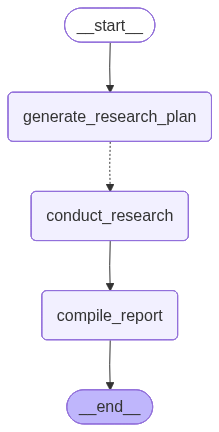

In [ ]:
report_agent

---

## 🚀 Execute the Agent

### Running the Complete Research Pipeline

Time to see our Planning Agent in action!

**What Happens When We Run:**

1. **User provides topic** → "Impact of AI on jobs"
2. **Planning Node** generates N research questions
3. **Research Nodes** answer all N questions **in parallel**
4. **Compilation Node** synthesizes findings into a report
5. **Output** is returned with the final report

**State Flow:**

```python
Initial State: {"topic": "Impact of AI on jobs"}
              ↓
After Planning: {"topic": "...", "research_qna": [], "questions": [Q1, Q2, ...], report = ""}
              ↓
After Research: {"topic": "...", "research_qna": [Q&A1, Q&A2, ...], "questions": [Q1, Q2, ...], report = ""}
              ↓
Final State: {"topic": "...", "research_qna": [Q&A1, Q&A2, ...], "questions": [Q1, Q2, ...], "report": "# Report..."}
```

In [ ]:
from IPython.display import display, Markdown

for state in report_agent.stream({"topic": "Artificial Intelligence"}):
    print(state)

{'generate_research_plan': {'questions': ['What are the core components of artificial intelligence?', 'How is artificial intelligence currently applied in various industries?', 'What are the ethical considerations surrounding artificial intelligence development?']}}
{'conduct_research': {'research_qna': [{'question': 'What are the core components of artificial intelligence?', 'answer': "Artificial Intelligence (AI) is a broad field that encompasses several core components, each contributing to the overall capability of intelligent systems. The main components include:\n\n1. Machine Learning (ML): This is the process by which computers improve their performance on tasks through experience or data. ML algorithms can be supervised, unsupervised, or reinforcement-based. For example, supervised learning is used for image recognition, where labeled examples guide the learning process.\n\n2. Natural Language Processing (NLP): NLP enables machines to understand, interpret, and generate human l

In [ ]:
display(Markdown(state['compile_report']['report']))

# Artificial Intelligence: Core Components, Applications, and Ethical Considerations

## Introduction

Artificial Intelligence (AI) stands as one of the most transformative technologies of the 21st century, revolutionizing how humans interact with machines and fundamentally reshaping industries worldwide. By simulating human intelligence, AI systems can analyze data, learn from experience, make decisions, and perform complex tasks with increasing autonomy and precision. This report explores the core components that constitute AI, examines its diverse applications across various sectors, and addresses the crucial ethical considerations surrounding its development and deployment.

---

## Core Components of Artificial Intelligence

Artificial Intelligence is a multidisciplinary domain, comprising several essential components that collectively enable machines to mimic human-like intelligence. Understanding these components provides insight into the inner workings and capabilities of AI systems.

1. **Machine Learning (ML)**  
   Machine Learning forms the foundation of modern AI, involving algorithms that enable computers to improve task performance based on data and experience. It includes:
   - **Supervised Learning**: Uses labeled datasets (e.g., image recognition with annotated images).  
   - **Unsupervised Learning**: Discovers patterns from unlabeled data.  
   - **Reinforcement Learning**: Learns by trial and error through feedback signals.

2. **Natural Language Processing (NLP)**  
   NLP allows machines to understand, interpret, and generate human language, enabling applications such as chatbots, language translation (e.g., Google Translate), and voice assistants.

3. **Computer Vision**  
   This component empowers machines to process and interpret visual inputs from the environment—recognizing objects, faces, or aiding complex tasks like autonomous vehicle navigation.

4. **Robotics**  
   Robotics integrates AI with mechanical systems to execute tasks autonomously or semi-autonomously, ranging from household appliances like robotic vacuum cleaners to sophisticated industrial robots.

5. **Knowledge Representation and Reasoning**  
   AI systems encode information about the world through ontologies and semantic networks, enabling reasoning and informed decision-making.

6. **Expert Systems**  
   These AI programs simulate human expert decision-making in specialized fields such as medical diagnosis, providing recommendations or assessments based on rule-based logic.

7. **Planning and Scheduling**  
   AI’s ability to devise sequences of actions to achieve goals is critical in logistics, manufacturing workflows, and autonomous systems.

Collectively, these components leverage algorithms (such as neural networks), computational models, and large datasets to enable AI's adaptability and interaction with complex environments.

---

## Applications of Artificial Intelligence Across Industries

AI’s impact spans a broad range of industries, driving innovation, automating processes, and enhancing decision-making.

### 1. Healthcare
- **Diagnosis and Treatment**: AI tools analyze imaging to detect diseases early (e.g., IBM Watson Health’s cancer detection).  
- **Drug Discovery**: AI accelerates research by predicting molecular interactions (e.g., AlphaFold’s protein structure prediction).  
- **Patient Care**: Virtual assistants and chatbots support patient monitoring and provide health advice remotely.

### 2. Finance
- **Fraud Detection**: AI detects anomalous transaction behaviors to prevent fraud.  
- **Algorithmic Trading**: Automated trading systems use machine learning to analyze market data and execute trades.  
- **Customer Service**: Chatbots enable personalized banking support.

### 3. Manufacturing
- **Predictive Maintenance**: AI anticipates equipment failures to minimize downtime.  
- **Quality Control**: Computer vision identifies defects during production.  
- **Supply Chain Optimization**: AI manages inventory and logistics efficiently.

### 4. Retail
- **Personalized Marketing**: AI analyzes consumer behavior to tailor promotions.  
- **Inventory Management**: Demand forecasting maintains optimal stock levels.  
- **Visual Search**: Customers can search products using images.

### 5. Transportation
- **Autonomous Vehicles**: AI powers self-driving technologies (e.g., Tesla Autopilot).  
- **Traffic Management**: AI optimizes traffic flow in smart cities.  
- **Logistics**: Route planning enhances delivery efficiency.

### 6. Agriculture
- **Crop Monitoring**: Satellite imagery analyzed by AI tracks crop health.  
- **Precision Farming**: AI-driven machinery optimizes planting and harvesting.  
- **Pest Detection**: Early identification of pest infestations.

### 7. Energy
- **Smart Grids**: AI balances and manages energy supply and demand.  
- **Renewable Energy Forecasting**: Predictive models estimate wind and solar power availability.  
- **Equipment Maintenance**: Predictive analytics prevent breakdowns of turbines and generators.

The pervasive integration of AI, harnessing machine learning, NLP, and computer vision, continues to accelerate with advances in data and computational power, fundamentally transforming global industries.

---

## Ethical Considerations in Artificial Intelligence Development

The development and deployment of AI raise important ethical challenges that must be addressed to ensure responsible innovation.

### 1. Fairness and Bias  
AI systems may inherit or exacerbate biases within training data, leading to discriminatory outcomes. For instance, facial recognition technologies have demonstrated higher error rates for people of color, risking misidentification and harm.

### 2. Transparency and Explainability  
Many AI models operate as opaque “black boxes,” obscuring the rationale behind their decisions. This lack of explanation is problematic in critical domains like healthcare and criminal justice.

### 3. Accountability  
Determining responsibility when AI causes harm is complex, involving developers, deployers, and potentially the AI itself. Establishing clear accountability frameworks is essential.

### 4. Privacy  
AI’s reliance on extensive datasets, often containing sensitive personal information, raises concerns about data protection and consent. The use of AI in surveillance can threaten individual privacy rights.

### 5. Security  
AI systems face risks from adversarial attacks that manipulate inputs to deceive AI, posing potential dangers in autonomous systems and cybersecurity.

### 6. Societal Impact and Employment  
Automation enabled by AI threatens job displacement, increasing economic inequality and highlighting the need for workforce reskilling programs.

### 7. Moral and Existential Risks  
Long-term concerns center on advanced AI potentially acting counter to human values, raising existential risk debates.

**Real-World Examples and Regulatory Responses:**  
- Amazon discontinued an AI recruiting tool due to gender bias in 2018.  
- The COMPAS algorithm used in US criminal justice has been criticized for racial bias.  
- The EU's GDPR enhances data privacy protections, influencing AI data handling.  
- Ethical guidelines such as the OECD AI Principles and the EU’s Artificial Intelligence Act aim to foster responsible AI governance.

---

## Conclusion

Artificial Intelligence represents a monumental leap in technology, built upon diverse components like machine learning, natural language processing, and computer vision that empower machines to perform increasingly sophisticated tasks. Its applications permeate numerous industries—from healthcare and finance to agriculture and energy—driving efficiency, innovation, and improved services globally.

However, AI’s promise comes with significant ethical challenges, including issues of fairness, transparency, accountability, privacy, and societal impact. Addressing these concerns through robust ethical standards, regulatory frameworks, and ongoing vigilance is critical to ensuring that AI develops in ways that are equitable, safe, and aligned with human values. As AI continues to evolve, balancing technological advancement with responsible stewardship will determine its ultimate benefit to society.

---

*This report offers a comprehensive overview of artificial intelligence’s foundational elements, practical implementations, and the ethical landscape that accompanies its integration into modern life.*

In [ ]:
for state in report_agent.stream({"topic": "Impact of AI on jobs"}):
    print(state)

{'generate_research_plan': {'questions': ['Which industries are most affected by AI automation?', 'How is AI changing the nature of job roles and required skills?', 'What are the long-term employment trends influenced by AI?', 'How does AI impact job creation versus job displacement?', 'What policies can mitigate negative effects of AI on employment?']}}
{'conduct_research': {'research_qna': [{'question': 'What are the long-term employment trends influenced by AI?', 'answer': 'The long-term employment trends influenced by AI are multifaceted and are reshaping labor markets globally. AI technologies have the potential to automate routine, repetitive tasks across various sectors, leading to both job displacement and transformation. For example, in manufacturing, AI-powered robots and automated systems have reduced the need for manual assembly line workers but have increased demand for roles such as robot maintenance technicians and AI system supervisors. In service industries, AI chatbot

In [ ]:
display(Markdown(state['compile_report']['report']))

# Impact of AI on Jobs

## Introduction

Artificial Intelligence (AI) is revolutionizing the global labor market, reshaping industries, job roles, and skill requirements at an unprecedented pace. While AI-driven automation enhances productivity and opens new economic opportunities, it simultaneously poses significant challenges, including job displacement and workforce transition demands. This report provides a comprehensive analysis of AI's impact on jobs, drawing insights from recent research on affected industries, changing job roles, long-term employment trends, the balance between job creation and displacement, and policy measures to mitigate adverse effects.

---

## Industries Most Affected by AI Automation

AI automation predominantly impacts industries characterized by repetitive, data-intensive, and predictable workflows. The following sectors stand out as most affected:

1. **Manufacturing**  
   - AI-powered robots enable high-precision operations, enhance quality control, and implement predictive maintenance.  
   - *Example*: Tesla’s AI-driven robotics in automotive assembly lines improve efficiency and minimize human error.  
   - *Evidence*: McKinsey estimates a 20% productivity increase due to AI integration in manufacturing.

2. **Transportation and Logistics**  
   - Automation optimizes route planning, inventory management, and enables autonomous vehicles.  
   - *Example*: Amazon employs AI for warehouse robotics and delivery route optimization.  
   - *Evidence*: PwC forecasts a 44% reduction in logistics costs by 2030 with self-driving trucks.

3. **Healthcare**  
   - AI supports diagnostics, patient monitoring, and administrative efficiency.  
   - *Example*: IBM Watson Health analyzes medical data to assist in cancer diagnosis.  
   - *Evidence*: Accenture projects $150 billion annual savings in US healthcare by 2026 via AI applications.

4. **Financial Services**  
   - AI drives algorithmic trading, fraud detection, chatbots, and credit scoring.  
   - *Example*: JPMorgan Chase utilizes AI for contract reviews and fraud analysis.  
   - *Evidence*: Deloitte reports a 22% reduction in banking operational costs due to AI.

5. **Retail**  
   - Automation enhances inventory control, personalizes recommendations, and enables cashier-less stores.  
   - *Example*: Amazon Go offers AI-powered checkout-free shopping.  
   - *Evidence*: Gartner predicts 85% of retail customer interactions will be AI-handled by 2025.

6. **Agriculture**  
   - AI-driven drones and sensors monitor crops, optimize irrigation, and forecast yields.  
   - *Example*: John Deere deploys AI-enabled machinery for precision farming.  
   - *Evidence*: The Food and Agriculture Organization estimates up to 30% crop yield increases through AI.

7. **Customer Service**  
   - Chatbots and virtual assistants automate routine inquiries.  
   - *Example*: Zendesk integrates AI chatbots to handle first-tier queries.  
   - *Evidence*: IBM suggests AI chatbots reduce customer service costs by up to 30%.

---

## Changes in Job Roles and Skill Requirements

AI is redefining job roles and reshaping the skillsets demanded across sectors through the following mechanisms:

- **Automation of Routine Tasks**  
  Reducing manual data entry and repetitive processing allows employees to engage in more strategic and supervisory roles.  
  *Example*: In finance, AI algorithms handle transaction processing, shifting focus to oversight and interpretation.

- **Emergence of New Job Roles**  
  New professions such as AI specialists, data scientists, machine learning engineers, and AI ethicists have been created, demanding advanced technical expertise in programming, data analysis, and ethical AI deployment.

- **Enhanced Decision-Making**  
  AI augments human judgment by offering predictive insights and analytics, necessitating abilities to collaborate with AI tools effectively.

- **Interdisciplinary Skill Sets**  
  Professionals combine domain knowledge with technical AI literacy, as seen in marketing roles employing AI tools for customer segmentation and campaign optimization.

- **Continuous Learning and Adaptability**  
  Rapid AI advancement compels lifelong learning, with increased participation in digital courses and certifications related to AI and data analytics.

- **Increased Importance of Soft Skills**  
  Creativity, problem-solving, emotional intelligence, and communication skills gain prominence as AI automates routine aspects.

**Supporting Evidence:**  
- The World Economic Forum (2020) forecasted displacement of 75 million jobs by 2022, alongside creation of 133 million AI-related roles.  
- IBM’s 2021 Skills Survey indicates over 50% professionals identify AI and data analytics as critical growth areas requiring upskilling.

---

## Long-Term Employment Trends Influenced by AI

AI is driving complex employment trends with both disruptive and generative effects:

- **Job Displacement and Transformation**  
  Routine and repetitive tasks are increasingly automated, displacing roles in manufacturing, customer service, and administration. Simultaneously, roles evolve to require maintenance, supervision, and collaboration with AI systems.

- **Emergence of New Occupations**  
  AI catalyzes growth in high-skill jobs, including data scientists, machine learning engineers, healthcare informaticians, and AI ethics specialists.

- **Shift Toward Cognitive and Emotional Skill-Based Jobs**  
  Roles emphasizing creativity, problem-solving, and emotional intelligence—such as education, creative arts, and human services—are expanding.

- **Job Polarization and Income Inequality Risks**  
  Middle-skill jobs decline, while high- and low-skill job demands grow, raising concerns about widening economic disparities.

- **Necessity for Continuous Upskilling**  
  The fluid nature of AI-driven change requires workforce agility and lifelong learning.

---

## AI’s Impact on Job Creation Versus Job Displacement

AI’s dual role in labor markets entails both displacement and creation effects:

- **Job Displacement**  
  - Primarily affects routine, manual, and predictable jobs across sectors.  
  - McKinsey estimates that by 2030, up to 375 million workers globally may need to change occupation categories.

- **Job Creation**  
  - Arises from new AI-related roles requiring advanced skills and expanding markets enabled by AI productivity gains.  
  - Healthcare, data science, AI maintenance, and creative industries see job growth.

- **Job Transformation**  
  - Many existing roles are being augmented rather than eliminated, emphasizing complex problem-solving and human judgment with AI support.  
  - *Example*: Legal professionals using AI for document review to focus on strategy.

- **Economic and Policy Moderators**  
  - The scale and speed of AI’s impact depend on regional policies, education systems, and economic contexts.

---

## Policy Measures to Mitigate Negative Effects of AI on Employment

To ensure equitable labor market transitions, effective policies are crucial:

1. **Education and Reskilling Programs**  
   - Promote continuous vocational training and digital literacy to align workforce skills with AI demands.  
   - *Example*: Singapore’s SkillsFuture initiative subsidizes lifelong learning efforts.

2. **Social Safety Nets**  
   - Strengthen unemployment benefits and explore wage insurance to protect displaced workers.  
   - *Example*: Finland's Universal Basic Income pilot tests income security during employment shifts.

3. **Job Transition Support**  
   - Provide career counseling, job-matching services, and relocation assistance to facilitate sectoral shifts.

4. **Encouraging Growth in AI-Complementary Sectors**  
   - Incentivize industries less prone to automation (healthcare, education, creative sectors).  
   - Support entrepreneurship to generate new employment avenues.

5. **Regulating Automation Pace and Scope**  
   - Implement guidelines for responsible AI adoption, including social impact assessments prior to large-scale automation.

6. **Taxation and Redistribution**  
   - Consider levies such as a “robot tax” to fund reskilling programs and social welfare, as debated in countries like South Korea.

**Evidence-based Outcomes:**  
- OECD studies reveal countries with strong active labor market policies manage technological disruptions more effectively.  
- Historical experience from the Industrial Revolution highlights the importance of adaptive policies in ensuring social stability.

---

## Conclusion

Artificial Intelligence is profoundly transforming the world of work—optimizing industry operations, reshaping occupational roles, and altering skill demands. While AI-driven automation threatens displacement primarily in routine and manual labor sectors, it simultaneously spurs the creation of novel, high-skill occupations and enhances job complexity. Long-term employment trends underscore a shift toward cognitive, creative, and interpersonal skill-based roles, demanding continuous learning and adaptability.

The net impact of AI on jobs depends heavily on proactive policy interventions focusing on education, social protection, job transition support, and responsible technological governance. Collaboration between governments, industries, educational institutions, and civil society is imperative to harness AI’s economic potential while safeguarding inclusive and equitable workforce development.

By understanding AI’s multifaceted effects and implementing comprehensive mitigation strategies, societies can navigate this technological revolution to promote sustainable employment and social well-being.